In [ ]:
import zipfile, os
with zipfile.ZipFile('internship_Dataset.zip', 'r') as z:
    z.extractall('.')
os.chdir('internship')
os.makedirs('scripts', exist_ok=True)
os.makedirs('Visualizations', exist_ok=True)
os.makedirs('Dataset', exist_ok=True)

In [ ]:
%%writefile scripts/vis.py
import os, glob, argparse
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def find_file(folder, keyword, skip=None):
    for f in os.listdir(folder):
        if keyword.lower() in f.lower():
            if skip and skip.lower() in f.lower():
                continue
            return os.path.join(folder, f)
def load_signal(path):
    with open(path) as f:
        lines = f.readlines()
    start = next(i for i,l in enumerate(lines) if l.strip()=='Data:') + 1
    rows = []
    for line in lines[start:]:
        parts = line.strip().split(';')
        if len(parts) < 2: continue
        try:
            t = pd.to_datetime(parts[0].strip().replace(',','.'), format='%d.%m.%Y %H:%M:%S.%f')
            v = float(parts[1].strip())
            rows.append((t, v))
        except: continue
    df = pd.DataFrame(rows, columns=['time','value']).set_index('time')
    return df
def load_events(path):
    events = []
    with open(path) as f:
        for line in f:
            if ';' not in line or line.startswith('Signal') or line.startswith('Start') or line.startswith('Unit'):
                continue
            p = line.strip().split(';')
            if len(p) < 3: continue
            try:
                date = p[0][:10]
                times = p[0][11:].split('-')
                s = pd.to_datetime(date+' '+times[0].replace(',','.'), format='%d.%m.%Y %H:%M:%S.%f')
                e = pd.to_datetime(date+' '+times[1].replace(',','.'), format='%d.%m.%Y %H:%M:%S.%f')
                if e < s: e += pd.Timedelta(days=1)
                events.append((s, e, p[2].strip()))
            except: continue
    return events
parser = argparse.ArgumentParser()
parser.add_argument('-name', required=True)
args = parser.parse_args()
folder = args.name
pid = os.path.basename(folder)

flow   = load_signal(find_file(folder, 'flow', skip='event'))
thorac = load_signal(find_file(folder, 'thorac'))
spo2   = load_signal(find_file(folder, 'spo2'))
events = load_events(find_file(folder, 'event'))

flow_plot   = flow[::8]
thorac_plot = thorac[::8]
chunk = pd.Timedelta(minutes=5)
t = flow_plot.index[0]
end = flow_plot.index[-1]
colors = {'Hypopnea': 'orange', 'Obstructive Apnea': 'red'}

with PdfPages(f'Visualizations/{pid}_visualization.pdf') as pdf:
    while t < end:
        t2 = t + chunk
        fig, axes = plt.subplots(3,1, figsize=(16,6), sharex=True)
        axes[0].plot(flow_plot[t:t2].index,   flow_plot[t:t2].value,   lw=0.4, color='steelblue')
        axes[1].plot(thorac_plot[t:t2].index, thorac_plot[t:t2].value, lw=0.4, color='orange')
        axes[2].plot(spo2[t:t2].index,        spo2[t:t2].value,        lw=0.6, color='gray')
        axes[0].set_ylabel('Nasal Flow')
        axes[1].set_ylabel('Thoracic')
        axes[2].set_ylabel('SpO2 (%)')
        axes[0].set_title(f'{pid}  {t.strftime("%H:%M")} - {min(t2,end).strftime("%H:%M")}')
        for s,e,typ in events:
            if e < t or s > t2: continue
            c = colors.get(typ, 'yellow')
            for ax in axes:
                ax.axvspan(s, e, alpha=0.3, color=c, label=typ)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()
        t = t2
print(f'saved {pid}_visualization.pdf')

Writing scripts/vis.py


In [ ]:
%%writefile scripts/create_dataset.py
import os, glob, argparse
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

def find_file(folder, keyword, skip=None):
    for f in os.listdir(folder):
        if keyword.lower() in f.lower():
            if skip and skip.lower() in f.lower():
                continue
            return os.path.join(folder, f)

def load_signal(path):
    with open(path) as f:
        lines = f.readlines()
    start = next(i for i,l in enumerate(lines) if l.strip()=='Data:') + 1
    rows = []
    for line in lines[start:]:
        parts = line.strip().split(';')
        if len(parts) < 2: continue
        try:
            t = pd.to_datetime(parts[0].strip().replace(',','.'), format='%d.%m.%Y %H:%M:%S.%f')
            v = float(parts[1].strip())
            rows.append((t,v))
        except: continue
    return pd.DataFrame(rows, columns=['time','value']).set_index('time')

def load_events(path):
    events = []
    with open(path) as f:
        for line in f:
            if ';' not in line or line.startswith(('Signal','Start','Unit')): continue
            p = line.strip().split(';')
            if len(p) < 3: continue
            try:
                date = p[0][:10]
                times = p[0][11:].split('-')
                s = pd.to_datetime(date+' '+times[0].replace(',','.'), format='%d.%m.%Y %H:%M:%S.%f')
                e = pd.to_datetime(date+' '+times[1].replace(',','.'), format='%d.%m.%Y %H:%M:%S.%f')
                if e < s: e += pd.Timedelta(days=1)
                events.append((s, e, p[2].strip()))
            except: continue
    return events

def bandpass(sig, fs=4, lo=0.17, hi=0.4):
    nyq = fs/2
    b,a = butter(2, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, sig)

def get_label(ws, we, events):
    dur = (we - ws).total_seconds()
    for s,e,typ in events:
        ov = (min(we,e) - max(ws,s)).total_seconds()
        if ov/dur > 0.5:
            return typ
    return 'Normal'

parser = argparse.ArgumentParser()
parser.add_argument('-in_dir',  required=True)
parser.add_argument('-out_dir', required=True)
args = parser.parse_args()

os.makedirs(args.out_dir, exist_ok=True)
all_rows = []

for pid in sorted(os.listdir(args.in_dir)):
    folder = os.path.join(args.in_dir, pid)
    if not os.path.isdir(folder): continue
    print(f'processing {pid}...')

    flow   = load_signal(find_file(folder, 'flow',   skip='event'))
    thorac = load_signal(find_file(folder, 'thorac'))
    spo2   = load_signal(find_file(folder, 'spo2'))
    events = load_events(find_file(folder, 'event'))

    df = pd.DataFrame({
        'flow':   flow.resample('250ms').mean().value,
        'thorac': thorac.resample('250ms').mean().value,
        'spo2':   spo2.resample('250ms').mean().value
    }).dropna()

    df['flow']   = bandpass(df.flow.values)
    df['thorac'] = bandpass(df.thorac.values)
    df['spo2']   = bandpass(df.spo2.values)

    ts = df.index
    vals = df.values
    W, step = 120, 60

    for i in range(0, len(df)-W+1, step):
        win = vals[i:i+W]
        label = get_label(ts[i], ts[i+W-1], events)
        all_rows.append([pid, str(ts[i]), label] + win.T.flatten().tolist())

cols = ['participant','window_start','label']
cols += [f'flow_{i}'   for i in range(120)]
cols += [f'thorac_{i}' for i in range(120)]
cols += [f'spo2_{i}'   for i in range(120)]

out = pd.DataFrame(all_rows, columns=cols)
out.to_csv(os.path.join(args.out_dir, 'breathing_dataset.csv'), index=False)
print(f'done. {len(out)} windows')
print(out.label.value_counts())

Writing scripts/create_dataset.py


In [ ]:
%%writefile scripts/train_model.py
import os, argparse
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from tensorflow.keras import layers, models

parser = argparse.ArgumentParser()
parser.add_argument('--dataset_dir', default='Dataset')
parser.add_argument('--epochs', type=int, default=20)
args = parser.parse_args()

df = pd.read_csv(os.path.join(args.dataset_dir, 'breathing_dataset.csv'))
labels = sorted(df.label.unique())
lmap   = {l:i for i,l in enumerate(labels)}
df['y'] = df.label.map(lmap)

feat_cols = [c for c in df.columns if c not in ['participant','window_start','label','y']]
participants = sorted(df.participant.unique())

def build_model(n_classes):
    model = models.Sequential([
        layers.Conv1D(16, 7, padding='same', activation='relu', input_shape=(120, 3)),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 5, padding='same', activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

all_pred, all_true = [], []

for test_p in participants:
    tr = df[df.participant != test_p]
    te = df[df.participant == test_p]

    Xtr = tr[feat_cols].values.reshape(-1, 120, 3)
    ytr = tr.y.values
    Xte = te[feat_cols].values.reshape(-1, 120, 3)
    yte = te.y.values

    model = build_model(len(labels))
    model.fit(Xtr, ytr, epochs=args.epochs, batch_size=64, verbose=0)

    preds = model.predict(Xte, verbose=0).argmax(axis=1)
    print(f'{test_p} accuracy: {accuracy_score(yte, preds):.4f}')
    all_pred.extend(preds)
    all_true.extend(yte)

all_pred = np.array(all_pred)
all_true = np.array(all_true)

print('\n===Overall Results===')
print(f'Accuracy  : {accuracy_score(all_true, all_pred):.4f}')
print(f'Precision : {precision_score(all_true, all_pred, average="weighted", zero_division=0):.4f}')
print(f'Recall    : {recall_score(all_true, all_pred, average="weighted", zero_division=0):.4f}')
cm = pd.DataFrame(confusion_matrix(all_true, all_pred), index=labels, columns=labels)
print('\nConfusion Matrix:')
print(cm)

Writing scripts/train_model.py


In [ ]:
import subprocess, os

os.chdir('/content/internship')

for p in sorted(os.listdir('Data')):
    r = subprocess.run(['python','scripts/vis.py','-name',f'Data/{p}'], capture_output=True, text=True)
    print(r.stdout if r.returncode==0 else r.stderr)

r = subprocess.run(['python','scripts/create_dataset.py','-in_dir','Data','-out_dir','Dataset'], capture_output=True, text=True)
print(r.stdout, r.stderr)

r = subprocess.run(['python','scripts/train_model.py','--dataset_dir','Dataset','--epochs','20'], capture_output=True, text=True)
print(r.stdout, r.stderr)

saved AP01_visualization.pdf

saved AP02_visualization.pdf

saved AP03_visualization.pdf

saved AP04_visualization.pdf

saved AP05_visualization.pdf

processing AP01...
processing AP02...
processing AP03...
processing AP04...
processing AP05...
done. 8800 windows
label
Normal               8028
Hypopnea              600
Obstructive Apnea     167
Body event              3
Mixed Apnea             2
Name: count, dtype: int64
 
AP01 accuracy: 0.9473
AP02 accuracy: 0.9101
AP03 accuracy: 0.9900
AP04 accuracy: 0.9105
AP05 accuracy: 0.7913

=== Overall Results ===
Accuracy  : 0.9119
Precision : 0.8324
Recall    : 0.9119

Confusion Matrix:
                   Body event  Hypopnea  Mixed Apnea  Normal  Obstructive Apnea
Body event                  0         0            0       3                  0
Hypopnea                    0         0            0     598                  2
Mixed Apnea                 0         0            0       2                  0
Normal                      0         1  

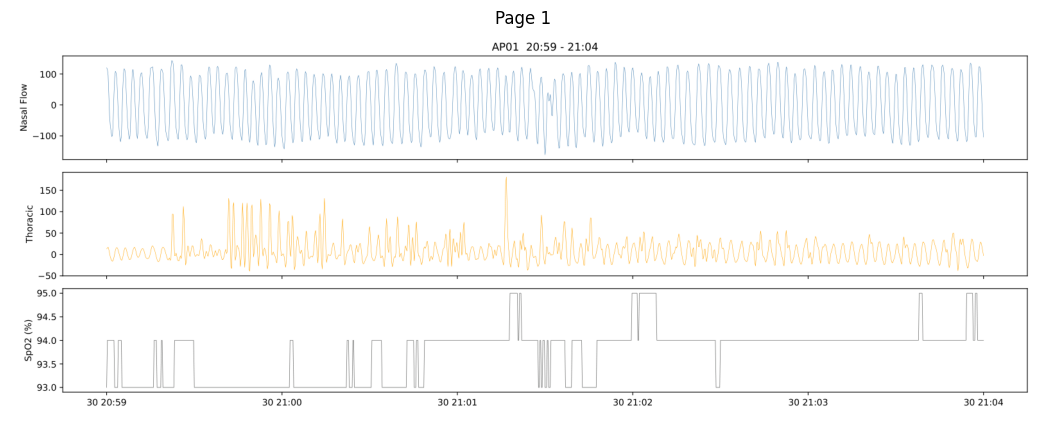

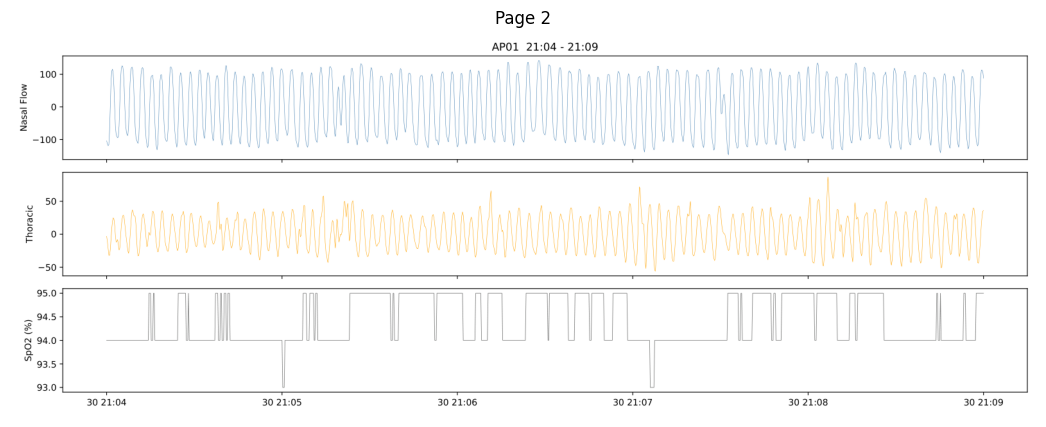

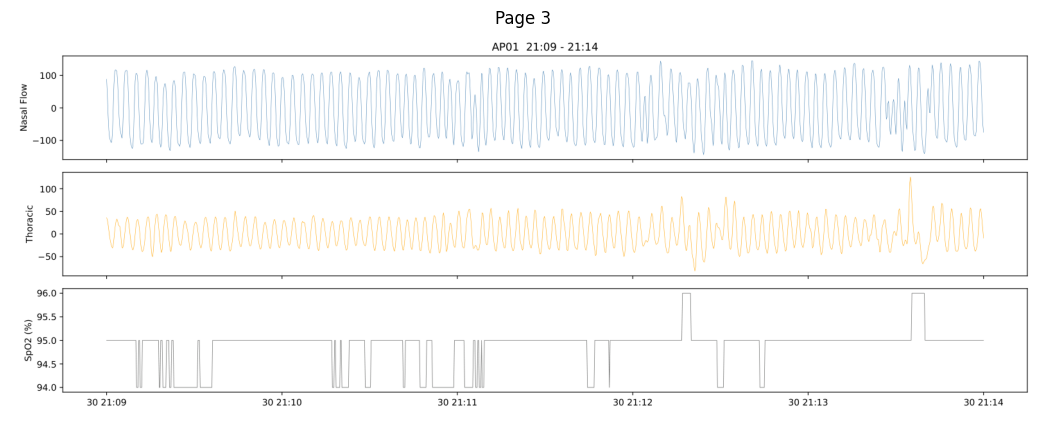

In [ ]:
import fitz
import numpy as np
import matplotlib.pyplot as plt

def show_pdf_pages(pdf_path, num_pages=3):
    doc = fitz.open(pdf_path)
    for i in range(min(num_pages, len(doc))):
        pix = doc[i].get_pixmap(dpi=100)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        plt.figure(figsize=(18, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Page {i+1}')
        plt.show()

show_pdf_pages('Visualizations/AP01_visualization.pdf', num_pages=3)

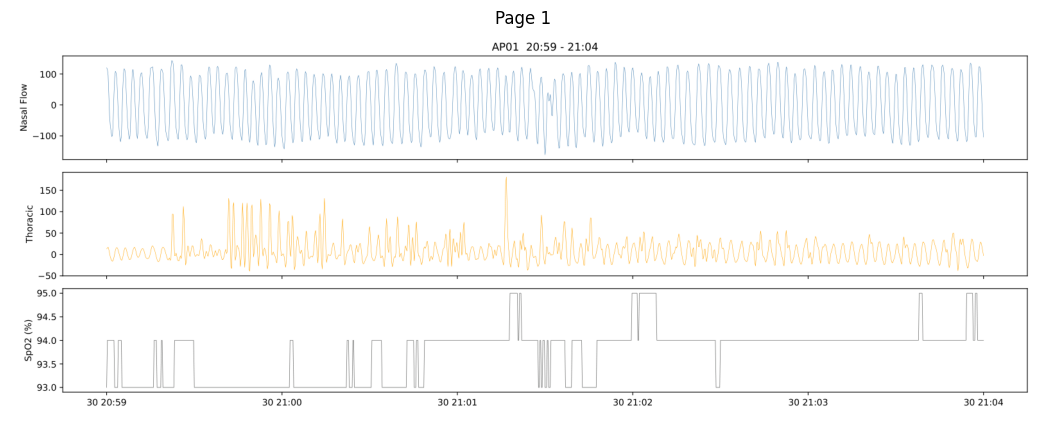

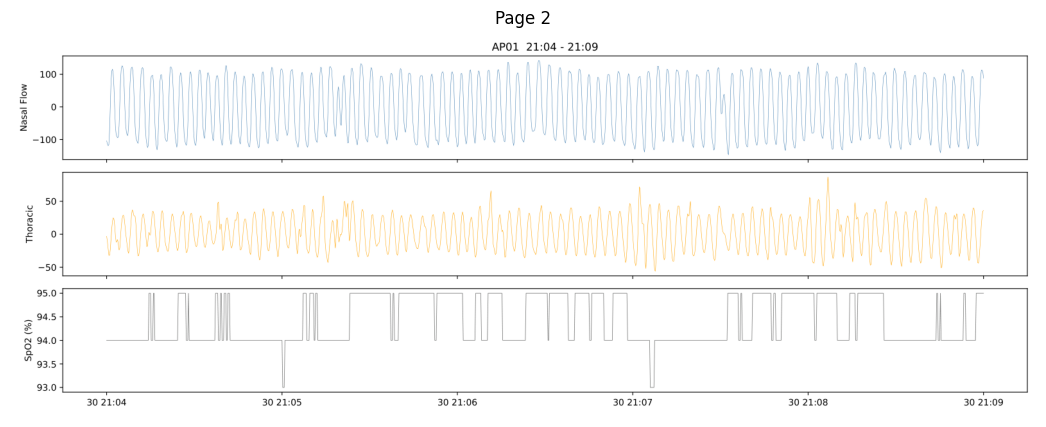

Total pages: 92


In [ ]:
show_pdf_pages('Visualizations/AP01_visualization.pdf', num_pages=2)

doc = fitz.open('Visualizations/AP01_visualization.pdf')
print(f'Total pages: {len(doc)}')

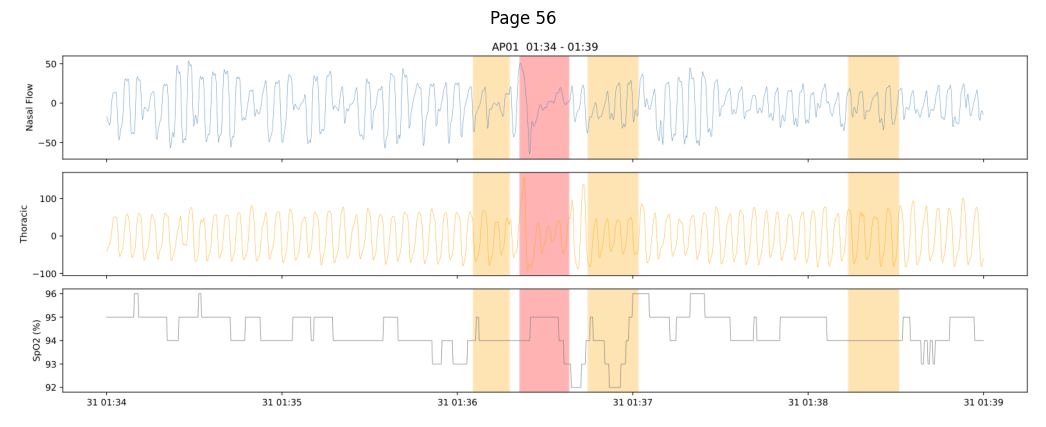

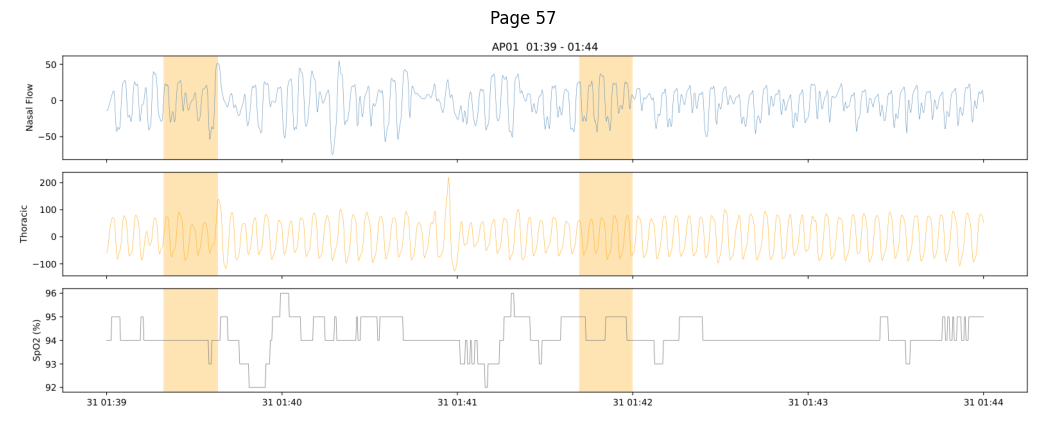

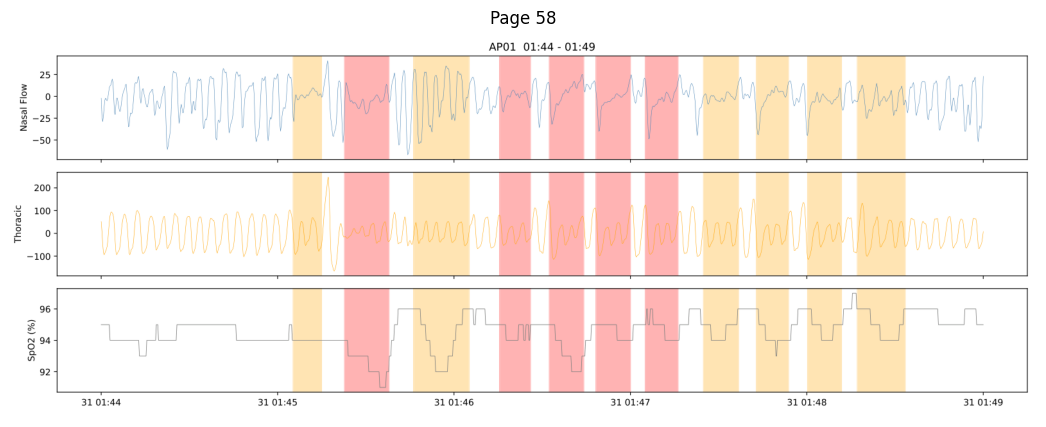

In [ ]:
def show_pages_from(pdf_path, start_page=55, n=3):
    doc = fitz.open(pdf_path)
    for i in range(start_page, min(start_page+n, len(doc))):
        pix = doc[i].get_pixmap(dpi=100)
        img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        plt.figure(figsize=(18,5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'Page {i+1}')
        plt.show()

show_pages_from('Visualizations/AP01_visualization.pdf', start_page=55, n=3)

In [ ]:
import shutil

shutil.make_archive('/content/SRIP_submission', 'zip', '/content', 'internship')

from google.colab import files
files.download('/content/SRIP_submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>